# Lab 01: RNN Sequence Modeling

**Module 01** | Read `notes/01-rnns-sequence-modeling.pdf` before running this notebook.

Train a character-level RNN on a small corpus. You will build the vocabulary, unroll sequences, run a full training loop, and plot the loss curve.

## How to use this notebook

1. **Run cells top to bottom** (Shift+Enter). Do not skip markdown cells; they explain the code.
2. **Read before you run.** Each section tells you what the next code block does, which terms mean, and what the printed output should look like.
3. **Use the comments in code.** Lines starting with `#` explain what each step does in plain language.
4. **Check the output.** After each code cell, compare your printed numbers to the "What to look for" notes.

Code is complete. You are not expected to fill in missing sections or debug skeleton code.


## Runtime device (CPU or GPU)

**What this section does:** PyTorch can run math on your **CPU** (the main processor) or on an **NVIDIA GPU** through **CUDA**. GPUs are faster for neural networks because they run many small matrix operations in parallel.

**Key terms:**
- **CPU:** Always available. Training works but can be slower on large models.
- **GPU / CUDA:** Optional hardware acceleration. If you have an NVIDIA GPU and drivers installed, PyTorch will use it automatically.
- **VRAM:** GPU memory. If you run out, reduce batch size.

The next cell prints which device is active so you know what to expect for training speed.


In [1]:
import torch

# Pick GPU if CUDA is available; otherwise fall back to CPU (labs still run).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")
else:
    print("Using CPU (no CUDA GPU detected).")
    print("All labs still run; training may take longer than on a GPU.")


Using GPU: NVIDIA GeForce GTX 1650
VRAM: 4.3 GB


## Key terms for this lab

| Term | Meaning |
|------|---------|
| **vocabulary** | The set of unique symbols (here, characters) the model can read and write. |
| **sequence** | An ordered list of tokens. Here, a string of characters read left to right. |
| **embedding** | A learned lookup table that turns each character ID into a small vector of numbers. |
| **hidden state** | The RNN's memory vector, updated at each timestep as it reads the sequence. |
| **logits** | Raw scores for each possible next character before converting to probabilities. |
| **softmax** | Turns logits into probabilities that sum to 1. Higher logit means higher probability. |
| **cross-entropy** | A loss that penalizes the model when it assigns low probability to the correct answer. |
| **epoch** | One full pass through the entire training dataset. |
| **batch** | A small group of examples processed together for speed and stable gradients. |
| **autoregressive generation** | Generating text one character at a time, feeding each prediction back as input. |
| **argmax** | Pick the single highest-scoring option (the most likely next character). |

Refer back to this table whenever a term appears in code or output.


## What problem are we solving?

Computers do not understand text directly. They need numbers. This lab teaches a neural network to **predict the next character** in a string, one step at a time. That is the same core idea behind large language models like GPT, just at character scale on a tiny corpus.

## What you will learn

- How raw text becomes training examples (windows of characters plus a target)
- How an RNN reads a sequence and produces a prediction
- What **logits**, **softmax**, and **cross-entropy** mean in practice
- How **backpropagation** updates weights through a training loop
- How to **generate new text** by letting the model predict its own next characters

No prior machine learning background is assumed. Read each markdown cell before running the code below it.


### Step 1: Build the corpus and vocabulary

**What this code does:** Creates a repeating text corpus, builds a character vocabulary, and slices the text into training windows of length 32. Each window's target is the character immediately after the window.

**Why we do it:** Before any neural network runs, we must turn text into numbered tensors. Keeping this step explicit shows exactly what the model learns from.


**What to look for in the output**

Corpus length around 1,750 characters, vocabulary size around 20 unique characters, and thousands of training examples. The vocabulary line should list every unique character in sorted order.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Project root and hyperparameters (settings we choose before training)
ROOT = Path("..").resolve()
SEQ_LEN = 32       # How many past characters the model sees at once
BATCH_SIZE = 64    # How many examples we process in parallel each step
HIDDEN_SIZE = 128  # Width of the RNN's internal memory vector
EPOCHS = 5         # How many times we loop over the full dataset
LR = 1e-2          # Learning rate: how big each weight update step is

# A small repeating corpus so training finishes quickly on CPU or GPU
CORPUS = "sequence modeling practice text " * 50

# Build vocabulary: sorted unique characters and bidirectional index maps
chars = sorted(set(CORPUS))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# Convert the entire corpus to a 1D tensor of character indices
indices = torch.tensor([char_to_idx[c] for c in CORPUS], dtype=torch.long)

# Sliding windows: input = SEQ_LEN chars, target = the very next char
inputs, targets = [], []
for start in range(len(indices) - SEQ_LEN):
    inputs.append(indices[start : start + SEQ_LEN])
    targets.append(indices[start + SEQ_LEN])
inputs = torch.stack(inputs)
targets = torch.stack(targets)

# Wrap tensors in a Dataset and DataLoader for batched, shuffled training
dataset = TensorDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Corpus length: {len(CORPUS):,} chars")
print(f"Vocabulary size: {vocab_size}")
print(f"Training examples: {len(dataset):,}")
print(f"\nVocabulary ({vocab_size} unique chars):")
print("  " + "".join(chars))


Corpus length: 1,600 chars
Vocabulary size: 18
Training examples: 1,568

Vocabulary (18 unique chars):
   acdegilmnopqrstux


### Step 2: Inspect training examples as readable strings

**What this code does:** Decodes a few input windows and their target characters back into readable text.

**Why we do it:** Seeing concrete examples makes the abstract "predict the next character" task tangible before we build the network.


**What to look for in the output**

Three pairs printed. Each input is a 32-character window; the target is a single character that should follow that window in the original corpus.


In [3]:
def decode_indices(idxs: torch.Tensor) -> str:
    # Turn a tensor of character indices back into a Python string
    return "".join(idx_to_char[i.item()] for i in idxs)


print("Three sample training pairs (input window -> target):")
print("-" * 60)
for i in range(3):
    window = decode_indices(inputs[i])
    target_ch = idx_to_char[targets[i].item()]
    print(f"  [{i}] input:  {window!r}")
    print(f"      target: {target_ch!r}")
    print()


Three sample training pairs (input window -> target):
------------------------------------------------------------
  [0] input:  'sequence modeling practice text '
      target: 's'

  [1] input:  'equence modeling practice text s'
      target: 'e'

  [2] input:  'quence modeling practice text se'
      target: 'q'



### Step 3: Define the CharRNN

**What this code does:** Builds a three-part network: embedding layer, RNN layer, and linear classifier. Also creates the loss function and optimizer.

**Why we do it:** This is the model we will train. The embedding turns character IDs into vectors; the RNN reads the sequence and updates its hidden state; the linear layer outputs logits (raw scores) for every character in the vocabulary.


**What to look for in the output**

A printed model summary showing Embedding, RNN, and Linear layers, plus a parameter count in the tens of thousands.


In [4]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int = 128):
        super().__init__()
        # Embedding: each character ID -> a vector of size hidden_size
        self.embed = nn.Embedding(vocab_size, hidden_size)
        # RNN: reads the sequence and produces an output at every timestep
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        # Linear layer: maps the final hidden state to vocab_size raw scores (logits)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embed(x)           # (batch, seq_len, hidden_size)
        output, _ = self.rnn(embedded)     # output at every timestep
        logits = self.fc(output[:, -1, :]) # use only the LAST timestep's output
        return logits


model = CharRNN(vocab_size, HIDDEN_SIZE).to(device)
criterion = nn.CrossEntropyLoss()  # compares logits to the correct character index
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParameters: {n_params:,}")


CharRNN(
  (embed): Embedding(18, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=18, bias=True)
)

Parameters: 37,650


**Concept: Logits and softmax**

- **Logits** are unbounded raw scores, one per vocabulary character. They are not probabilities yet.
- **Softmax** squashes logits into probabilities between 0 and 1 that sum to 1.
- **Argmax** picks the character with the highest probability (greedy choice).

An untrained model produces nearly random logits, so its top predictions should look arbitrary.


### Step 4: One forward pass before training

**What this code does:** Runs a single training example through the untrained model and prints the predicted character, the true target, and the top-3 candidates with probabilities.

**Why we do it:** A forward pass before training establishes a baseline. After training, you can compare how much predictions improve.


**What to look for in the output**

The prediction will likely be wrong. Top-3 probabilities should be spread out (not dominated by one character), showing the model has not learned yet.


In [5]:
@torch.no_grad()  # disable gradient tracking for inference-only code
def show_prediction(model, input_seq: torch.Tensor, target_idx: int) -> None:
    model.eval()
    # Add batch dimension: (seq_len,) -> (1, seq_len)
    logits = model(input_seq.unsqueeze(0).to(device))
    # Convert raw scores to probabilities with softmax
    probs = torch.softmax(logits, dim=-1).squeeze(0)
    # Greedy decode: pick the highest-scoring character
    pred_idx = logits.argmax(dim=-1).item()
    top3_probs, top3_idx = probs.topk(3)
    print(f"  Input:    {decode_indices(input_seq)!r}")
    print(f"  Target:   {idx_to_char[target_idx]!r}")
    print(f"  Predicted:{idx_to_char[pred_idx]!r}  {'correct' if pred_idx == target_idx else 'wrong'}")
    print("  Top-3 next-char candidates:")
    for rank, (prob, idx) in enumerate(zip(top3_probs, top3_idx), start=1):
        ch = idx_to_char[idx.item()]
        print(f"    {rank}. {ch!r}  (prob {prob.item():.4f})")


print("Untrained model, one example:")
show_prediction(model, inputs[0], targets[0].item())


Untrained model, one example:
  Input:    'sequence modeling practice text '
  Target:   's'
  Predicted:'g'  wrong
  Top-3 next-char candidates:
    1. 'g'  (prob 0.0873)
    2. 'i'  (prob 0.0738)
    3. 'a'  (prob 0.0686)


**Concept: Cross-entropy and backpropagation**

- **Cross-entropy loss** measures how surprised the model is by the correct answer. If the model assigns high probability to the right character, loss is low.
- **Backpropagation** (`loss.backward()`) computes how each weight should change to reduce the loss.
- **Optimizer step** (`optimizer.step()`) actually applies those small weight updates.

One **epoch** means the model has seen every training example once.


### Step 5: Training loop

**What this code does:** Trains the RNN for several epochs. Each epoch loops over shuffled batches, computes loss, runs backprop, and updates weights. Tracks loss and character accuracy.

**Why we do it:** This is where learning happens. Watch loss fall and accuracy rise as the model picks up patterns in the repeating corpus.


**What to look for in the output**

Loss should decrease across epochs (e.g., from around 3.0 toward 1.0 or lower). Character accuracy should climb well above the random baseline of about 5% (1 / vocab_size).


In [6]:
def epoch_accuracy(model, inputs_t: torch.Tensor, targets_t: torch.Tensor, batch_size: int = 256) -> float:
    # Fraction of examples where argmax prediction matches the target character
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for start in range(0, len(inputs_t), batch_size):
            batch_x = inputs_t[start : start + batch_size].to(device)
            batch_y = targets_t[start : start + batch_size].to(device)
            preds = model(batch_x).argmax(dim=-1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    return correct / total


loss_history = []
acc_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()       # clear old gradients from the previous step
        logits = model(batch_x)     # forward pass
        loss = criterion(logits, batch_y)  # compare predictions to true next chars
        loss.backward()             # backprop: compute gradients
        optimizer.step()            # update weights
        epoch_loss += loss.item() * batch_x.size(0)

    avg_loss = epoch_loss / len(dataset)
    acc = epoch_accuracy(model, inputs, targets)
    loss_history.append(avg_loss)
    acc_history.append(acc)
    print(f"Epoch {epoch:02d}/{EPOCHS}  loss {avg_loss:.4f}  char accuracy {acc * 100:.1f}%")


Epoch 01/5  loss 0.3896  char accuracy 96.9%
Epoch 02/5  loss 0.0623  char accuracy 96.9%
Epoch 03/5  loss 0.0456  char accuracy 100.0%
Epoch 04/5  loss 0.0046  char accuracy 100.0%
Epoch 05/5  loss 0.0011  char accuracy 100.0%


### Step 6: Plot the loss curve

**What this code does:** Draws a line chart of cross-entropy loss per epoch.

**Why we do it:** A falling curve confirms the model is learning. A flat line suggests something is wrong (learning rate, device, or data alignment).


**What to look for in the output**

A downward-sloping line with markers at each epoch. If the line is flat from the start, check that cells ran in order and `device` is set.


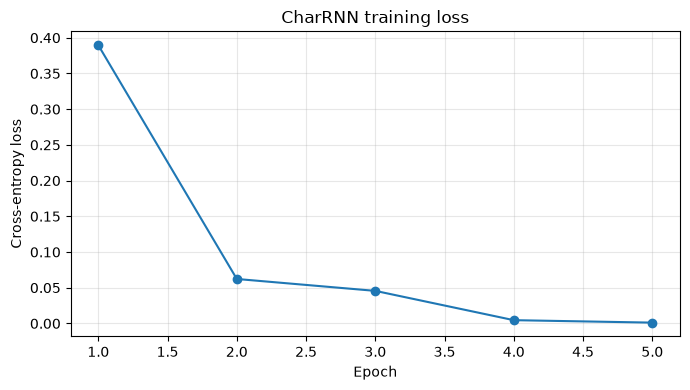

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("CharRNN training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 7: Post-training evaluation on held examples

**What this code does:** Shows predictions on several examples after training and compares final accuracy to a random-guess baseline.

**Why we do it:** Accuracy well above `1 / vocab_size` proves the model learned real patterns, not just memorized batch order.


**What to look for in the output**

Most predictions should be correct on this repeating corpus. Full-dataset accuracy should be much higher than the random-guess baseline (about 5% for ~20 characters).


In [8]:
print("Post-training predictions on 5 examples:")
print("-" * 60)

def sample_eval_indices(n: int, k: int = 5) -> list[int]:
    """Pick k spread-out row indices in [0, n-1] without going out of bounds."""
    if n <= 0:
        return [0]
    if n <= k:
        return list(range(n))
    return sorted({0, n // 4, n // 2, (3 * n) // 4, n - 1})

eval_indices = sample_eval_indices(len(inputs))
for i in eval_indices:
    show_prediction(model, inputs[i], targets[i].item())
    print()

final_acc = epoch_accuracy(model, inputs, targets)
random_baseline = 1.0 / vocab_size
print(f"Full-dataset char accuracy: {final_acc * 100:.2f}%")
print(f"Random-guess baseline:      {random_baseline * 100:.2f}%")
print(f"(Evaluated at dataset indices: {eval_indices})")


Post-training predictions on 5 examples:
------------------------------------------------------------
  Input:    'sequence modeling practice text '
  Target:   's'
  Predicted:'s'  correct
  Top-3 next-char candidates:
    1. 's'  (prob 0.9981)
    2. 'm'  (prob 0.0011)
    3. 'x'  (prob 0.0005)

  Input:    ' modeling practice text sequence'
  Target:   ' '
  Predicted:' '  correct
  Top-3 next-char candidates:
    1. ' '  (prob 0.9996)
    2. 'p'  (prob 0.0003)
    3. 'q'  (prob 0.0001)

  Input:    'g practice text sequence modelin'
  Target:   'g'
  Predicted:'g'  correct
  Top-3 next-char candidates:
    1. 'g'  (prob 0.9996)
    2. 'c'  (prob 0.0002)
    3. 'e'  (prob 0.0001)

  Input:    'ce text sequence modeling practi'
  Target:   'c'
  Predicted:'c'  correct
  Top-3 next-char candidates:
    1. 'c'  (prob 0.9995)
    2. 'n'  (prob 0.0001)
    3. 'u'  (prob 0.0001)

  Input:    ' sequence modeling practice text'
  Target:   ' '
  Predicted:' '  correct
  Top-3 next-char cand

**Concept: Autoregressive generation**

At training time the model sees **real** past characters. At generation time it must use **its own** predictions as input for the next step. That loop (predict, append, slide window, repeat) is called **autoregressive generation**. ChatGPT-style models use the same idea with word pieces instead of characters.


### Step 8: Autoregressive text generation

**What this code does:** Starts from a short seed string and generates 80 new characters by repeatedly feeding the model its own argmax predictions.

**Why we do it:** This is the payoff: turning a next-character predictor into a text generator.


**What to look for in the output**

Generated text should echo phrases from the training corpus (like 'sequence modeling practice'). It will not be perfect prose, but it should look like learned patterns, not random letters.


In [9]:
@torch.no_grad()
def generate_text(model, seed: str, n_chars: int = 80) -> str:
    model.eval()
    text = seed
    for _ in range(n_chars):
        # Take the last SEQ_LEN characters as the input window
        window = text[-SEQ_LEN:]
        idxs = torch.tensor([[char_to_idx[c] for c in window]], device=device)
        logits = model(idxs)
        # Greedy: always pick the single most likely next character
        next_idx = logits.argmax(dim=-1).item()
        text += idx_to_char[next_idx]
    return text


seed = "sequence mod"
generated = generate_text(model, seed, n_chars=80)
print(f"Seed ({len(seed)} chars): {seed!r}")
print(f"Generated ({len(generated)} chars):")
print(generated)


Seed (12 chars): 'sequence mod'
Generated (92 chars):
sequence modeling practice text sequence modeling practice text sequence modeling practice t


### Summary

You built a character-level RNN, turned text into numbered training pairs, watched loss and accuracy improve, and generated new text one character at a time. Real-world language models use the same training objective at a larger scale with bigger vocabularies and longer contexts.


In [10]:
print("=" * 60)
print("Lab 01 summary")
print("=" * 60)
print(f"  Corpus length:     {len(CORPUS):,} chars")
print(f"  Vocabulary:        {vocab_size} unique characters")
print(f"  Training examples: {len(dataset):,}")
print(f"  Model parameters:  {n_params:,}")
print(f"  Final loss:        {loss_history[-1]:.4f}")
print(f"  Final accuracy:    {acc_history[-1] * 100:.2f}%")
print(f"  Seed:              {seed!r}")
print(f"  Generated length:  {len(generated)} chars")
print("=" * 60)


Lab 01 summary
  Corpus length:     1,600 chars
  Vocabulary:        18 unique characters
  Training examples: 1,568
  Model parameters:  37,650
  Final loss:        0.0011
  Final accuracy:    100.00%
  Seed:              'sequence mod'
  Generated length:  92 chars
